<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/rul_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupKFold,train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Bidirectional, Dense, Dropout,
                                     Conv1D, BatchNormalization, MaxPooling1D,
                                     Flatten, Multiply, Add, LayerNormalization,
                                     GlobalAveragePooling1D, MultiHeadAttention)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED            = 42
SEQUENCE_LENGTH = 30
RUL_THRESHOLD   = 125
N_SPLITS        = 5
tf.random.set_seed(SEED)
np.random.seed(SEED)


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. RAW DATA LOADING ONLY — no scaling, no feature engineering yet
# ══════════════════════════════════════════════════════════════════════════════
train_df = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)
train_df.columns = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

max_cycle       = train_df.groupby('id')['cycle'].max().reset_index().rename(columns={'cycle':'max_cycle'})
train_df        = train_df.merge(max_cycle, on='id')
train_df['RUL'] = (train_df['max_cycle'] - train_df['cycle']).clip(upper=RUL_THRESHOLD)
train_df.drop(columns=['max_cycle'], inplace=True)

base_feature_cols = [c for c in train_df.columns if c not in ['id','cycle','RUL']]

# ══════════════════════════════════════════════════════════════════════════════
# 3. SEQUENCE CREATION
# ══════════════════════════════════════════════════════════════════════════════
def create_sequences(df, feat_cols, seq_len):

    X_seqs, y_seqs = [], []

    for eid in df['id'].unique():

        engine = df[df['id'] == eid]
        arr    = engine[feat_cols + ['RUL']].values

        for i in range(len(arr) - seq_len):
            X_seqs.append(arr[i:i+seq_len, :-1])
            y_seqs.append(arr[i+seq_len, -1])

    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

# ══════════════════════════════════════════════════════════════════════════════
# 4. NASA SCORE & METRICS
# ══════════════════════════════════════════════════════════════════════════════
def nasa_score(y_true, y_pred):

    diff = y_pred - y_true

    return float(np.sum(np.where(
        diff < 0,
        np.exp(-diff/13) - 1,
        np.exp(diff/10) - 1
    )))

def report_metrics(name, true, pred):

    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    nasa = nasa_score(true, pred)

    print(f"{name:35s} → RMSE:{rmse:.3f}  MAE:{mae:.3f}  NASA:{nasa:.1f}")

    return rmse, mae, nasa

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. MODEL BUILDERS
# ══════════════════════════════════════════════════════════════════════════════
def build_bilstm(seq_len, n_features):
    inputs  = Input(shape=(seq_len, n_features))
    x       = Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.05))(inputs)
    x       = Dropout(0.1)(x)
    attn    = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.05)(x, x)
    x       = LayerNormalization()(Add()([x, attn]))
    ffn     = Dense(128, activation='relu')(x)
    ffn     = Dense(x.shape[-1])(ffn)
    x       = LayerNormalization()(Add()([x, ffn]))
    x       = GlobalAveragePooling1D()(x)
    x       = Dense(64, activation='relu')(x)
    x       = Dropout(0.1)(x)
    outputs = Dense(1)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer=Adam(8e-5), loss=Huber(), metrics=['mae'])
    return model

def build_cnn(seq_len, n_features):
    inputs  = Input(shape=(seq_len, n_features))
    x       = Conv1D(64, kernel_size=3, activation='relu')(inputs)
    x       = BatchNormalization()(x)
    x       = MaxPooling1D(pool_size=2)(x)
    x       = Dropout(0.2)(x)
    x       = Conv1D(32, kernel_size=3, activation='relu')(x)
    x       = BatchNormalization()(x)
    w       = Dense(32, activation='softmax')(x)
    x       = Flatten()(Multiply()([x, w]))
    x       = Dense(64, activation='relu')(x)
    x       = Dropout(0.3)(x)
    outputs = Dense(1)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss=Huber(), metrics=['mae'])
    return model


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════
def get_callbacks_bilstm():
    return [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=6, min_lr=1e-6, verbose=1)
    ]

def get_callbacks_cnn():
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.8, patience=5, min_lr=1e-5, verbose=1)
    ]


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. GROUPKFOLD LOOP — scaler fitted inside fold on train only
# ══════════════════════════════════════════════════════════════════════════════
engine_ids = train_df['id'].unique()
gkf        = GroupKFold(n_splits=N_SPLITS)

fold_results   = []
lstm_histories = []
cnn_histories  = []
all_val_lstm   = []
all_val_cnn    = []
all_val_true   = []

for fold, (train_eng_idx, val_eng_idx) in enumerate(
    gkf.split(engine_ids, groups=engine_ids)
):

    print(f"\n{'='*55}")
    print(f"  FOLD {fold+1} / {N_SPLITS}")
    print(f"{'='*55}")

    train_engines = engine_ids[train_eng_idx]
    val_engines   = engine_ids[val_eng_idx]

    train_eng = train_df[train_df['id'].isin(train_engines)].copy()
    val_eng   = train_df[train_df['id'].isin(val_engines)].copy()

    feat_cols = base_feature_cols.copy()

    fold_scaler = MinMaxScaler(feature_range=(0,1))

    train_eng[feat_cols] = fold_scaler.fit_transform(train_eng[feat_cols])
    val_eng[feat_cols]   = fold_scaler.transform(val_eng[feat_cols])

    X_train, y_train = create_sequences(train_eng, feat_cols, SEQUENCE_LENGTH)
    X_val,   y_val   = create_sequences(val_eng,   feat_cols, SEQUENCE_LENGTH)

    print(f"  Train: {X_train.shape} | Val: {X_val.shape}")

    n_features  = X_train.shape[2]

    bilstm_model = build_bilstm(SEQUENCE_LENGTH, n_features)
    cnn_model    = build_cnn(SEQUENCE_LENGTH, n_features)

    h_lstm = bilstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=64,
        callbacks=get_callbacks_bilstm(),
        verbose=0
    )

    h_cnn = cnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=64,
        callbacks=get_callbacks_cnn(),
        verbose=0
    )

    lstm_histories.append(h_lstm)
    cnn_histories.append(h_cnn)

    vp_lstm = bilstm_model.predict(X_val, verbose=0).flatten()
    vp_cnn  = cnn_model.predict(X_val, verbose=0).flatten()

    all_val_lstm.extend(vp_lstm)
    all_val_cnn.extend(vp_cnn)
    all_val_true.extend(y_val)

    print(f"\n  Fold {fold+1} Validation:")

    rmse_l, mae_l, nasa_l = report_metrics(
        "  BiLSTM + Attention",
        y_val,
        vp_lstm
    )

    rmse_c, mae_c, nasa_c = report_metrics(
        "  CNN   + Attention",
        y_val,
        vp_cnn
    )

    fold_results.append({
        "fold"      : fold+1,
        "lstm_rmse" : rmse_l,
        "lstm_mae"  : mae_l,
        "lstm_nasa" : nasa_l,
        "cnn_rmse"  : rmse_c,
        "cnn_mae"   : mae_c,
        "cnn_nasa"  : nasa_c,
    })

print(f"\n{'='*55}")
print("  CROSS-VALIDATION SUMMARY")
print(f"{'='*55}")

lstm_rmses = [r["lstm_rmse"] for r in fold_results]
cnn_rmses  = [r["cnn_rmse"] for r in fold_results]

print(f"  BiLSTM RMSE : {np.mean(lstm_rmses):.4f} ± {np.std(lstm_rmses):.4f}")
print(f"  CNN    RMSE : {np.mean(cnn_rmses):.4f} ± {np.std(cnn_rmses):.4f}")


  FOLD 1 / 5
  Train: (14256, 30, 24) | Val: (3375, 30, 24)

Epoch 41: ReduceLROnPlateau reducing learning rate to 6.399999838322402e-05.

Epoch 54: ReduceLROnPlateau reducing learning rate to 5.119999987073243e-05.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.000800000037997961.

Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0006400000303983689.

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0005120000336319208.

  Fold 1 Validation:
  BiLSTM + Attention                → RMSE:15.537  MAE:10.217  NASA:18035.6
  CNN   + Attention                 → RMSE:19.126  MAE:13.764  NASA:42290.1

  FOLD 2 / 5
  Train: (14038, 30, 24) | Val: (3593, 30, 24)

Epoch 24: ReduceLROnPlateau reducing learning rate to 6.399999838322402e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 5.119999987073243e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 4.0960000478662555e-05.

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.2767999800853435e-05.



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 8. OPTIMIZED ENSEMBLE WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════
all_val_lstm = np.array(all_val_lstm)
all_val_cnn  = np.array(all_val_cnn)
all_val_true = np.array(all_val_true)

def ensemble_rmse(w):
    pred = w[0] * all_val_lstm + w[1] * all_val_cnn
    return np.sqrt(mean_squared_error(all_val_true, pred))

result = minimize(
    ensemble_rmse, x0=[0.5, 0.5],
    bounds=[(0,1),(0,1)],
    constraints={'type':'eq', 'fun': lambda w: w[0]+w[1]-1}
)
w_lstm, w_cnn = result.x
print(f"\n  Optimized Weights → BiLSTM: {w_lstm:.3f} | CNN: {w_cnn:.3f}")



  Optimized Weights → BiLSTM: 0.803 | CNN: 0.197


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 9. FINAL RETRAIN ON FULL DATA
#    scaler fitted on ALL training data — correct since test is truly held out
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("  FINAL TRAINING ON FULL TRAINING DATA")
print(f"{'='*55}")

full_eng  = train_df.copy()
feat_cols = base_feature_cols.copy()

final_scaler = MinMaxScaler(feature_range=(0,1))

full_eng[feat_cols] = final_scaler.fit_transform(
    full_eng[feat_cols]
)

X_full, y_full = create_sequences(
    full_eng,
    feat_cols,
    SEQUENCE_LENGTH
)

n_features = X_full.shape[2]

final_bilstm = build_bilstm(SEQUENCE_LENGTH, n_features)
final_cnn    = build_cnn(SEQUENCE_LENGTH, n_features)

final_bilstm.fit(
    X_full,
    y_full,
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks_bilstm(),
    verbose=0
)

final_cnn.fit(
    X_full,
    y_full,
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks_cnn(),
    verbose=0
)


  FINAL TRAINING ON FULL TRAINING DATA


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae,learning_rate.
  callback.on_epoch_end(epoch, logs)



  TEST RESULTS
CNN   + Attention                   → RMSE:18.980  MAE:13.856  NASA:887.3
BiLSTM + Attention                  → RMSE:15.338  MAE:11.446  NASA:423.6
Ensemble (optimized)                → RMSE:14.982  MAE:10.981  NASA:399.1


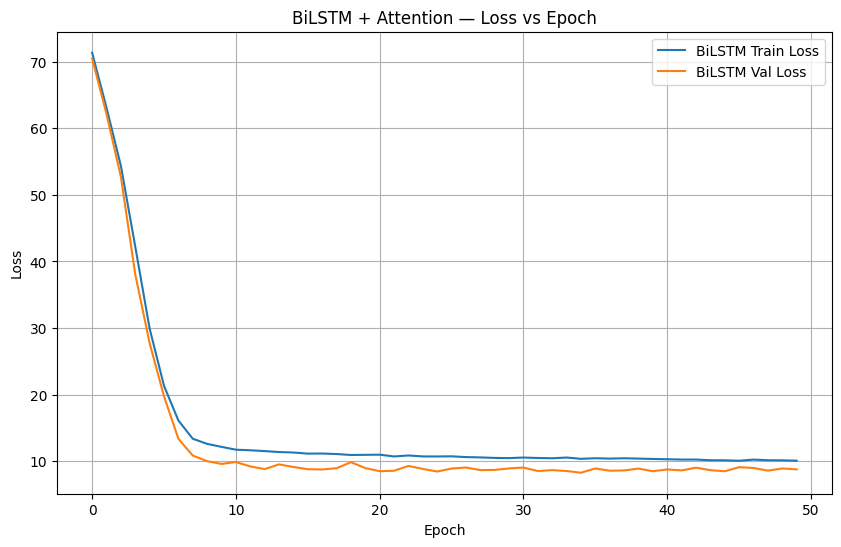

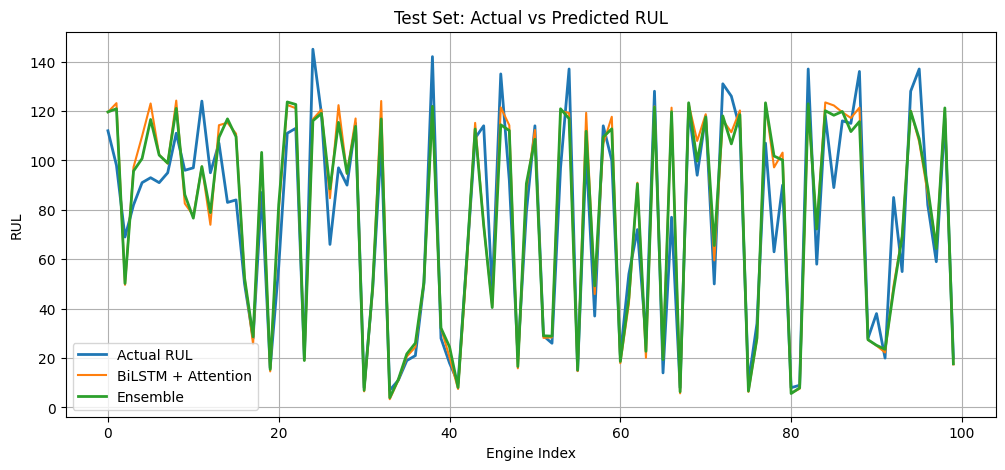

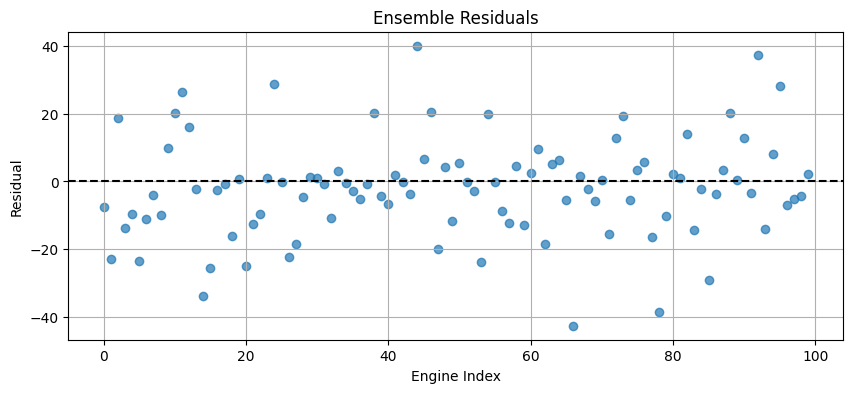

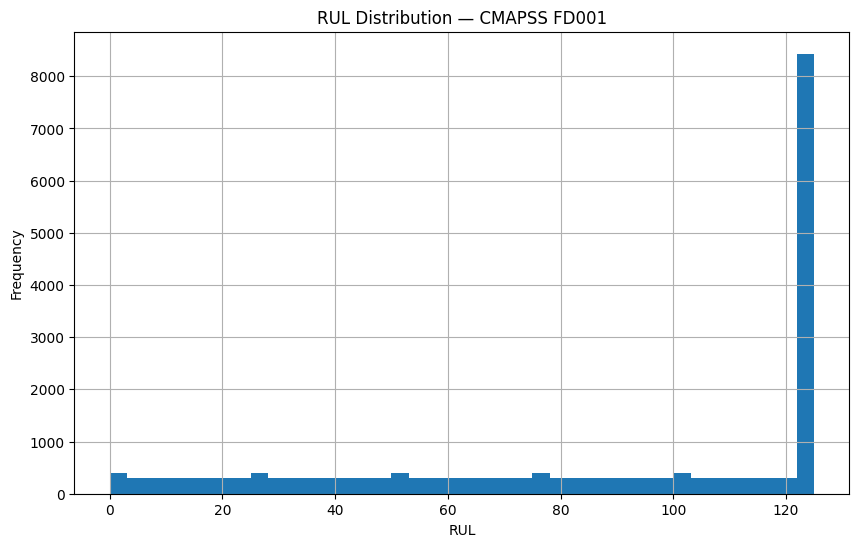

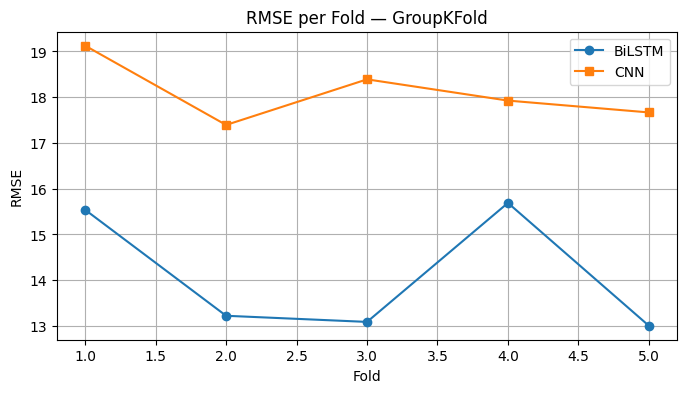

In [10]:

# ══════════════════════════════════════════════════════════════════════════════
# 10. TEST SET — final_scaler (trained on all train data) used here ✅
# ══════════════════════════════════════════════════════════════════════════════
test_df = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]

test_df.columns = [
    'id','cycle','op1','op2','op3'
] + [f's{i}' for i in range(1,22)]

test_eng  = test_df.copy()
feat_cols = base_feature_cols.copy()

test_eng[feat_cols] = final_scaler.transform(
    test_eng[feat_cols]
)

X_test = np.array([
    test_eng[test_eng['id'] == eid][feat_cols]
    .values[-SEQUENCE_LENGTH:]
    for eid in test_eng['id'].unique()
], dtype=np.float32)

y_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None
).values.flatten()

pred_lstm = final_bilstm.predict(
    X_test,
    verbose=0
).flatten()

pred_cnn = final_cnn.predict(
    X_test,
    verbose=0
).flatten()

pred_ensemble = (
    w_lstm * pred_lstm +
    w_cnn  * pred_cnn
)

print(f"\n{'='*55}")
print("  TEST RESULTS")
print(f"{'='*55}")

report_metrics(
    "CNN   + Attention",
    y_test,
    pred_cnn
)

report_metrics(
    "BiLSTM + Attention",
    y_test,
    pred_lstm
)

report_metrics(
    "Ensemble (optimized)",
    y_test,
    pred_ensemble
)

plt.figure(figsize=(10,6))
plt.plot(
    lstm_histories[-1].history['loss'],
    label='BiLSTM Train Loss'
)

plt.plot(
    lstm_histories[-1].history['val_loss'],
    label='BiLSTM Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BiLSTM + Attention — Loss vs Epoch')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12,5))

plt.plot(
    y_test,
    label='Actual RUL',
    linewidth=2
)

plt.plot(
    pred_lstm,
    label='BiLSTM + Attention',
    linewidth=1.5
)

plt.plot(
    pred_ensemble,
    label='Ensemble',
    linewidth=2
)

plt.title('Test Set: Actual vs Predicted RUL')
plt.xlabel('Engine Index')
plt.ylabel('RUL')
plt.legend()
plt.grid()
plt.show()

residuals = y_test - pred_ensemble

plt.figure(figsize=(10,4))

plt.scatter(
    range(len(residuals)),
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--',
    color='black'
)

plt.title('Ensemble Residuals')
plt.xlabel('Engine Index')
plt.ylabel('Residual')
plt.grid()
plt.show()

plt.figure(figsize=(10,6))

plt.hist(
    train_df['RUL'],
    bins=40
)

plt.xlabel('RUL')
plt.ylabel('Frequency')
plt.title('RUL Distribution — CMAPSS FD001')
plt.grid()
plt.show()

plt.figure(figsize=(8,4))

plt.plot(
    range(1, N_SPLITS+1),
    lstm_rmses,
    marker='o',
    label='BiLSTM'
)

plt.plot(
    range(1, N_SPLITS+1),
    cnn_rmses,
    marker='s',
    label='CNN'
)

plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('RMSE per Fold — GroupKFold')
plt.legend()
plt.grid()
plt.show()